In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

In [2]:
nav = pd.read_csv("../data/processed/02_nav_history.csv")

performance = pd.read_csv("../data/processed/07_scheme_performance.csv")

fund = pd.read_csv("../data/raw/01_fund_master.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [3]:
print(nav.shape)
print(performance.shape)
print(fund.shape)

print(nav.columns)
print(performance.columns)
print(fund.columns)

(46000, 3)
(40, 19)
(40, 15)
Index(['amfi_code', 'date', 'nav'], dtype='object')
Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')
Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='object')


In [4]:
nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [5]:
print(nav["daily_return"].describe())

print("\nMissing Daily Returns:")
print(nav["daily_return"].isnull().sum())

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

Missing Daily Returns:
40


In [6]:
cagr = nav.groupby("amfi_code").agg(
    start_nav=("nav", "first"),
    end_nav=("nav", "last"),
    start_date=("date", "first"),
    end_date=("date", "last")
).reset_index()

cagr["years"] = (
    (cagr["end_date"] - cagr["start_date"]).dt.days
    / 365.25
)

cagr["cagr"] = (
    (cagr["end_nav"] / cagr["start_nav"]) **
    (1 / cagr["years"])
) - 1

cagr.head()

,amfi_code,start_nav,end_nav,start_date,end_date,years,cagr
0,100016,520.4608,583.6113,2022-01-03,2026-05-29,4.399726,0.026371
1,100025,26.3169,31.8843,2022-01-03,2026-05-29,4.399726,0.044582
2,100033,107.3758,342.0072,2022-01-03,2026-05-29,4.399726,0.301232
3,101206,305.0996,773.2939,2022-01-03,2026-05-29,4.399726,0.235384
4,101207,38.5736,53.9836,2022-01-03,2026-05-29,4.399726,0.079388


In [7]:
print(cagr[["amfi_code", "years", "cagr"]].head())

   amfi_code     years      cagr
0     100016  4.399726  0.026371
1     100025  4.399726  0.044582
2     100033  4.399726  0.301232
3     101206  4.399726  0.235384
4     101207  4.399726  0.079388


In [8]:
risk_free_rate = 0.065   # 6.5%
trading_days = 252

sharpe = (
    nav.groupby("amfi_code")["daily_return"]
       .agg(["mean", "std"])
       .reset_index()
)

sharpe["sharpe_ratio"] = (
    (sharpe["mean"] * trading_days - risk_free_rate)
    /
    (sharpe["std"] * (trading_days ** 0.5))
)

sharpe.head()

,amfi_code,mean,std,sharpe_ratio
0,100016,0.000142,0.009164,-0.201517
1,100025,0.000170,0.002460,-0.567095
2,100033,0.001080,0.011929,1.093699
3,101206,0.000852,0.009177,1.027213
4,101207,0.000424,0.016251,0.162661


In [10]:
print(sharpe[["amfi_code","sharpe_ratio"]].head())

   amfi_code  sharpe_ratio
0     100016     -0.201517
1     100025     -0.567095
2     100033      1.093699
3     101206      1.027213
4     101207      0.162661


In [9]:
negative_returns = nav.copy()

negative_returns["downside_return"] = negative_returns["daily_return"]

negative_returns.loc[
    negative_returns["downside_return"] > 0,
    "downside_return"
] = 0

sortino = (
    negative_returns.groupby("amfi_code")
    .agg(
        mean_return=("daily_return","mean"),
        downside_std=("downside_return","std")
    )
    .reset_index()
)

sortino["sortino_ratio"] = (
    (sortino["mean_return"] * 252 - risk_free_rate)
    /
    (sortino["downside_std"] * (252**0.5))
)

sortino.head()

,amfi_code,mean_return,downside_std,sortino_ratio
0,100016,0.000142,0.005163,-0.357702
1,100025,0.000170,0.001382,-1.009643
2,100033,0.001080,0.006632,1.967316
3,101206,0.000852,0.004989,1.889576
4,101207,0.000424,0.009256,0.285576


In [11]:
print(sortino[["amfi_code","sortino_ratio"]].head())

   amfi_code  sortino_ratio
0     100016      -0.357702
1     100025      -1.009643
2     100033       1.967316
3     101206       1.889576
4     101207       0.285576


In [12]:
nav["running_max"] = (
    nav.groupby("amfi_code")["nav"]
       .cummax()
)

nav["drawdown"] = (
    nav["nav"] /
    nav["running_max"]
) - 1

max_dd = (
    nav.groupby("amfi_code")["drawdown"]
       .min()
       .reset_index()
)

max_dd.rename(
    columns={"drawdown":"max_drawdown"},
    inplace=True
)

max_dd.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [13]:
print(max_dd.head())

   amfi_code  max_drawdown
0     100016     -0.247344
1     100025     -0.043083
2     100033     -0.162172
3     101206     -0.112916
4     101207     -0.354469


In [14]:
alpha_beta = performance[["amfi_code", "alpha", "beta"]]

print(alpha_beta.head())

   amfi_code  alpha  beta
0     119551   0.87  0.89
1     119552   1.78  0.87
2     119598   1.23  0.89
3     119599   1.13  1.04
4     119120   1.60  0.22


In [15]:
scorecard = performance.copy()

scorecard["return_rank"] = scorecard["return_3yr_pct"].rank(ascending=False)
scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(ascending=False)
scorecard["alpha_rank"] = scorecard["alpha"].rank(ascending=False)
scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank(ascending=True)
scorecard["drawdown_rank"] = scorecard["max_drawdown_pct"].rank(ascending=False)

scorecard["score"] = (
    (40 - scorecard["return_rank"]) * 0.30 +
    (40 - scorecard["sharpe_rank"]) * 0.25 +
    (40 - scorecard["alpha_rank"]) * 0.20 +
    (40 - scorecard["expense_rank"]) * 0.15 +
    (40 - scorecard["drawdown_rank"]) * 0.10
)

scorecard = scorecard.sort_values("score", ascending=False)

scorecard[
    ["amfi_code","scheme_name","score"]
].head(10)

,amfi_code,scheme_name,score
22,120843,Kotak Flexicap Fund - Regular - Growth,27.700
2,119598,SBI Small Cap Fund - Regular Plan - Growth,27.250
14,120507,ICICI Pru Liquid Fund - Regular - Growth,27.200
9,100025,HDFC Short Term Debt Fund - Regular - Growth,27.100
21,120842,Kotak Emerging Equity Fund - Regular - Growth,26.300
3,119599,SBI Small Cap Fund - Direct Plan - Growth,26.200
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,25.675
29,101207,ABSL Small Cap Fund - Regular - Growth,25.000
23,120844,Kotak Liquid Fund - Regular - Growth,24.650
33,102887,UTI Flexi Cap Fund - Regular - Growth,24.125


In [16]:
alpha_beta.to_csv("../reports/alpha_beta.csv", index=False)

In [17]:
scorecard.to_csv("../reports/fund_scorecard.csv", index=False)

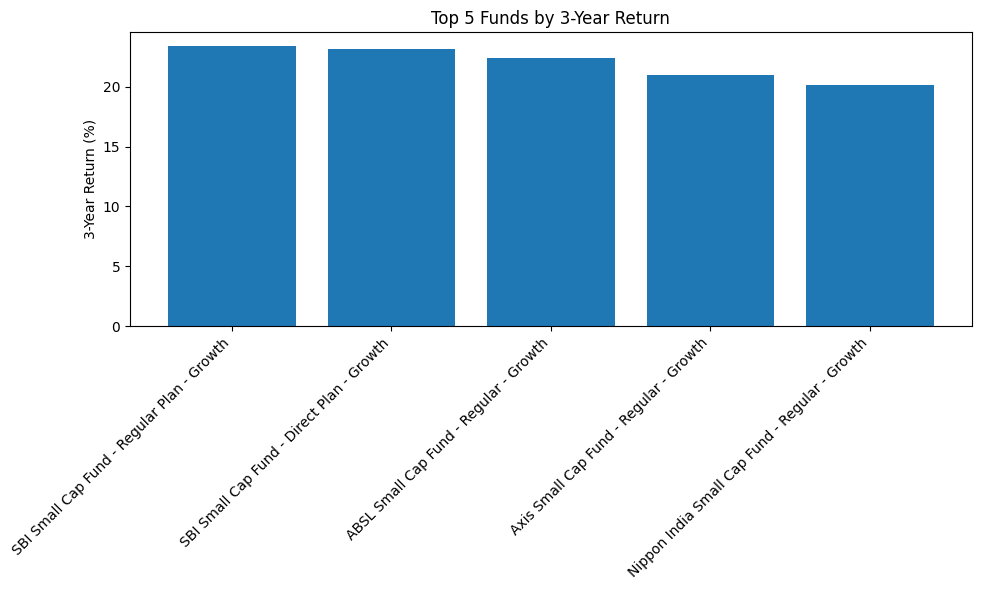

In [18]:
top5 = performance.nlargest(5, "return_3yr_pct")

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(
    top5["scheme_name"],
    top5["return_3yr_pct"]
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("3-Year Return (%)")
plt.title("Top 5 Funds by 3-Year Return")

plt.tight_layout()

plt.savefig("../reports/benchmark_comparison.png", dpi=300)

plt.show()